# Spiking Diffusion for Audio: Exploratory Spike-Based Denoising

## Overview
This notebook implements a prototype combining spiking neural networks (SNNs) with a diffusion-style denoising objective for audio signals.

## Objective
- Encode audio signals into spike trains using rate-based encoding
- Train a spiking neural network to predict noise added to the signal
- Generate a waveform by iteratively applying a learned denoising process

## Motivation
Diffusion models learn to recover data from progressively corrupted inputs. This experiment explores whether a similar noise prediction objective can be implemented using spike-based neural networks for 1D audio signals.

## Scope
This is an exploratory prototype using a synthetic waveform. The goal is to validate the learning setup rather than achieve realistic audio generation.

## Environment Setup

This section initializes libraries for tensor computation, spiking neural networks, signal processing, and audio export.

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import snntorch as snn
from snntorch import spikegen
from snntorch import surrogate
from core.diffusion import SpikingDiffusion
from core.models import SpikingDenoiser

device = "cuda" if torch.cuda.is_available() else "cpu"


## Experiment Parameters

The following parameters define the audio length, diffusion steps, training duration, and spike simulation length.

In [3]:
# Parameters

L = 4000              # audio length
T = 50                # diffusion steps
num_steps = 25        # SNN time steps
epochs = 1000
sr = 16000

## Model Components

### SpikingDenoiser
The `SpikingDenoiser` is adapted for 1D signal processing and operates on spike-encoded waveform inputs.

- Input signals are first converted into spike trains using rate encoding  
- Temporal processing is performed using Leaky Integrate-and-Fire (LIF) neurons over multiple timesteps  
- The network outputs a signal estimate based on spike activity  

Unlike the image diffusion setup, the model here is trained to map noisy inputs directly to structured waveform outputs.

### SpikingDiffusion
The `SpikingDiffusion` module defines a forward corruption process for the waveform.

- A timestep-dependent noise schedule is used  
- Noise is added to the signal to produce progressively corrupted versions  
- The corrupted signal serves as input for training the spiking network  

### Training Objective
The model is trained to recover the original waveform from its corrupted version.

- A random diffusion timestep is sampled  
- The waveform is corrupted using the diffusion process  
- The corrupted signal is encoded into spike trains  
- The network predicts a refined signal representation  
- Mean squared error (MSE) is used between the predicted and original waveform  

### Iterative Signal Refinement
During inference, a signal is generated starting from random initialization.

- The current signal is repeatedly spike-encoded and passed through the network  
- The model output is used as the updated signal at each step  
- This produces a progressively refined waveform  

This process resembles a diffusion-style reverse procedure, but is implemented as an iterative deterministic update rather than a full probabilistic sampling process.

In [4]:
# Initialize spiking denoiser network for 1D signal processing
model = SpikingDenoiser(input_dim=L, hidden_dim=1024).to(device)

# Initialize diffusion process for forward corruption
diff = SpikingDiffusion()

## Synthetic Audio Signal

A synthetic waveform is constructed using a combination of sinusoidal signals. This provides a structured input for evaluating denoising behavior.

The waveform is normalized and converted into a range suitable for spike-based encoding.

In [5]:
# Generate synthetic waveform composed of multiple sinusoidal components
# This provides a structured signal for evaluating denoising behavior

t = np.linspace(0, 1, sr)

audio = (
    0.5*np.sin(2*np.pi*200*t) +
    0.3*np.sin(2*np.pi*400*t) +
    0.2*np.sin(2*np.pi*800*t)
)

audio = audio / np.max(np.abs(audio))

waveform = torch.tensor(audio[:L]).float().to(device)

# Normalize waveform to [0,1] range for compatibility with rate-based spike encoding
waveform = (waveform - waveform.min())/(waveform.max()-waveform.min())

## Training Procedure

The model is trained to predict the original waveform from noisy inputs generated through a diffusion-style process.

### Steps:
1. Sample a random diffusion timestep
2. Add noise to the waveform using the diffusion process
3. Encode the noisy signal into spike trains
4. Predict the signal using the spiking network
5. Optimize using mean squared error loss

In [6]:
# Training loop: learn mapping from noisy signal to structured waveform
# using spike-based encoding and gradient-based optimization

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("Starting training...")

for epoch in range(epochs):
    # Sample a random diffusion timestep
    t_step = torch.randint(0, T, (1,), device=device)

    # Generate Poisson-distributed noise for signal corruption
    noise = diff.poisson_noise(waveform)

    # Apply forward diffusion to obtain corrupted signal
    x_t = diff.q_sample(waveform, t_step, noise)

    # Encode corrupted signal into spike trains using rate-based encoding
    spk = spikegen.rate(torch.clamp(x_t,0,1), num_steps=num_steps)

    # Predict signal representation from spike-based input
    pred_rate = model(spk, t_step)

    # Compute reconstruction loss between predicted and original waveform
    loss = loss_fn(pred_rate.squeeze(), waveform)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Log training progress at regular intervals
    if epoch % 100 == 0:
        print(f"Epoch {epoch} Loss {loss.item():.4f}")

print("Training complete")

Starting training...
Epoch 0 Loss 0.2879
Epoch 100 Loss 0.0202
Epoch 200 Loss 0.0180
Epoch 300 Loss 0.0176
Epoch 400 Loss 0.0184
Epoch 500 Loss 0.0198
Epoch 600 Loss 0.0219
Epoch 700 Loss 0.0233
Epoch 800 Loss 0.0248
Epoch 900 Loss 0.0259
Training complete


## Reverse Diffusion Sampling

After training, a waveform is generated by iteratively applying the learned transformation starting from a noisy initialization.

At each step:
- The current signal is spike-encoded
- The spiking network produces an updated signal estimate
- The estimate is used as the input for the next step

In [7]:
# Reverse diffusion-style sampling:
# iteratively refine signal starting from random initialization

model.eval()

x = torch.randn(1, L).to(device) * 0.5   # Initialize signal with random values as starting point
x = torch.clamp(x, 0, 1)

for t in reversed(range(T)):          
    spk = spikegen.rate(torch.clamp(x, 0, 1), num_steps=num_steps)
    
    rate = torch.relu(model(spk, torch.tensor([t]).to(device)))     # Model predicts updated signal representation at current step
    
    x = rate      # Update signal estimate using model output (deterministic update)
    
    
    # Optional: introduce stochastic variation using centered Poisson noise
    # x = rate + (torch.poisson(rate) - rate) * 0.1   # centered Poisson noise

# Normalize final output
x = torch.clamp(x, 0, 1)

## Generated Waveform

The generated signal is saved as an audio file and plotted for visual inspection.

In [8]:
# Save generated waveform to audio file for inspection

generated = x.squeeze().cpu().detach().numpy()

generated = generated / np.max(np.abs(generated))

sf.write("generated_speech.wav", generated, sr)

print("Generated speech saved!")


Generated speech saved!


## Quantitative Signal Metrics

The generated waveform is evaluated using basic signal statistics:

- Signal power
- Variance
- Spectral energy
- Zero-crossing rate
- Average spike rate

These metrics provide a summary of the generated signal characteristics.

In [18]:
# Compute basic signal statistics for generated waveform

print("Generation Metrics:")

# Compute average signal power
signal_power = np.mean(generated**2)

# Compute variance of waveform
variance = np.var(generated)

# Compute spectral energy using Fourier transform
fft = np.fft.fft(generated)
spectral_energy = np.mean(np.abs(fft))

# Compute zero-crossing rate (signal oscillation measure)
zcr = np.mean(np.abs(np.diff(np.sign(generated)))) / 2

# Estimate average spike rate after encoding
spk = spikegen.rate(torch.tensor(generated).unsqueeze(0).to(device), num_steps=num_steps)
spike_rate = torch.mean(spk.float()).item()

print("Signal Power:", signal_power)
print("Waveform Variance:", variance)
print("Spectral Energy:", spectral_energy)
print("Zero Crossing Rate:", zcr)
print("Average Spike Rate:", spike_rate)

Generation Metrics:
Signal Power: 0.41476643
Waveform Variance: 0.17327279
Spectral Energy: 9.350738
Zero Crossing Rate: 0.050512627
Average Spike Rate: 0.4899500012397766


## Waveform Visualization

The generated waveform is plotted to visually inspect its structure and temporal behavior.

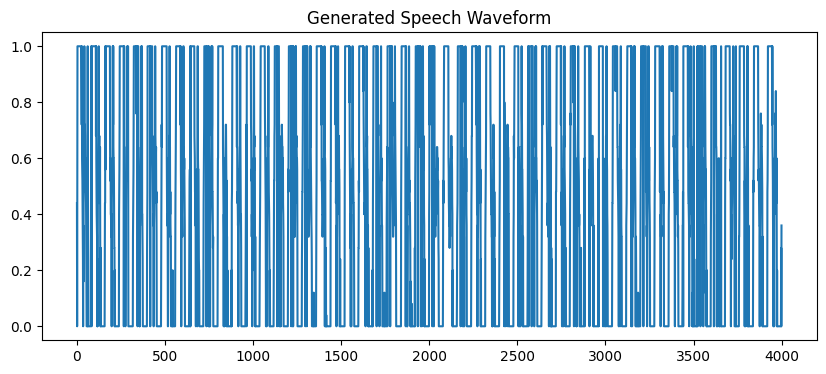

In [16]:
# Visualize generated waveform in time domain

plt.figure(figsize=(10,4))
plt.plot(generated)
plt.title("Generated Speech Waveform")
plt.show()


## Conclusion

This notebook presents a prototype combining spiking neural networks with a diffusion-inspired training objective for audio signals.

### Observations
- The model learns to map noisy inputs to structured signals using spike-based representations
- Iterative application of the model produces a stable waveform from random initialization
- Signal metrics indicate that the generated waveform has consistent statistical structure

### Interpretation
The results suggest that spike-based models can be used to learn iterative signal refinement processes resembling diffusion-style denoising.

### Limitations
- The experiment uses a synthetic waveform rather than real audio data
- The model predicts signal values directly rather than explicitly modeling noise
- The generated output is limited in complexity and realism

### Takeaway
This experiment demonstrates a basic framework for applying diffusion-inspired training to spiking neural networks in the context of audio signal generation.